## Load Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

In [2]:
marketing_data = pd.read_csv('Datasets/marketing_data.csv')
marketing_csv = marketing_data.copy()
marketing_csv.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,1826,1970,Graduation,Divorced,"$84,835.00",0,0,6/16/14,0,189,...,6,1,0,0,0,0,0,1,0,SP
1,1,1961,Graduation,Single,"$57,091.00",0,0,6/15/14,0,464,...,7,5,0,0,0,0,1,1,0,CA
2,10476,1958,Graduation,Married,"$67,267.00",0,1,5/13/14,0,134,...,5,2,0,0,0,0,0,0,0,US
3,1386,1967,Graduation,Together,"$32,474.00",1,1,5/11/14,0,10,...,2,7,0,0,0,0,0,0,0,AUS
4,5371,1989,Graduation,Single,"$21,474.00",1,0,4/8/14,0,6,...,2,7,1,0,0,0,0,1,0,SP


In [3]:
marketing_csv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   2240 non-null   int64 
 1   Year_Birth           2240 non-null   int64 
 2   Education            2240 non-null   object
 3   Marital_Status       2240 non-null   object
 4    Income              2216 non-null   object
 5   Kidhome              2240 non-null   int64 
 6   Teenhome             2240 non-null   int64 
 7   Dt_Customer          2240 non-null   object
 8   Recency              2240 non-null   int64 
 9   MntWines             2240 non-null   int64 
 10  MntFruits            2240 non-null   int64 
 11  MntMeatProducts      2240 non-null   int64 
 12  MntFishProducts      2240 non-null   int64 
 13  MntSweetProducts     2240 non-null   int64 
 14  MntGoldProds         2240 non-null   int64 
 15  NumDealsPurchases    2240 non-null   int64 
 16  NumWeb

In [4]:
marketing_csv.describe()

,ID,Year_Birth,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,5592.159821,1968.805804,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,...,2.662054,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.149107,0.009375
std,3246.662198,11.984069,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,...,2.923101,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.356274,0.096391
min,0.000000,1893.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2828.250000,1959.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,...,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5458.500000,1970.000000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,...,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,8427.750000,1977.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,...,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,11191.000000,1996.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,...,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


<h4 style="color:purple">After importing the data, examine variables such as Dt_Customer and Income to verify their accurate importation.</h4>

In [5]:
# Examine the dataset
marketing_csv.isna().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
 Income                24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Response                0
Complain                0
Country                 0
dtype: int64

## Observation from Dataset

Handle the below observations. Before analysation.

1. Income variable name is having trailing spaces. Should remove this.
2. There are missing values in the income variable that should be fixed.
3. The income variable's datatype is object. It should be numeric. Should fix.
4. Dt_Customer variable data type should be date.

In [6]:
# Removing trailing spaces from the columns
marketing_csv.columns = marketing_csv.columns.str.strip()

In [7]:
marketing_csv.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Response', 'Complain', 'Country'],
      dtype='object')

In [8]:
# Examine the Dt_Customer,Income variable
marketing_csv[['Dt_Customer', 'Income']].head()

,Dt_Customer,Income
0,6/16/14,"$84,835.00"
1,6/15/14,"$57,091.00"
2,5/13/14,"$67,267.00"
3,5/11/14,"$32,474.00"
4,4/8/14,"$21,474.00"


In [9]:
print(marketing_csv['Dt_Customer'].dtype)

# Change Dt_Customer data type to date
marketing_csv['Dt_Customer'] = pd.to_datetime(marketing_csv['Dt_Customer'],format='%m/%d/%y')
print(marketing_csv['Dt_Customer'].dtype)

object
datetime64[ns]


In [10]:
marketing_csv.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,1826,1970,Graduation,Divorced,"$84,835.00",0,0,2014-06-16,0,189,...,6,1,0,0,0,0,0,1,0,SP
1,1,1961,Graduation,Single,"$57,091.00",0,0,2014-06-15,0,464,...,7,5,0,0,0,0,1,1,0,CA
2,10476,1958,Graduation,Married,"$67,267.00",0,1,2014-05-13,0,134,...,5,2,0,0,0,0,0,0,0,US
3,1386,1967,Graduation,Together,"$32,474.00",1,1,2014-05-11,0,10,...,2,7,0,0,0,0,0,0,0,AUS
4,5371,1989,Graduation,Single,"$21,474.00",1,0,2014-04-08,0,6,...,2,7,1,0,0,0,0,1,0,SP


<h4 style="color:purple">2. There are missing income values for some customers. </h4>

---
    Conduct missing value imputation, considering that customers with similar education and marital status tend to have comparable yearly incomes, on average. 
    
---
    It may be necessary to cleanse the data before proceeding. Specifically, scrutinize the categories of education and marital status for data cleaning.

In [11]:
marketing_csv['Income'].isna().sum()

np.int64(24)

In [12]:
# Education and Marital Status
print(marketing_csv['Education'].unique())
print(marketing_csv['Marital_Status'].unique())

['Graduation' 'PhD' '2n Cycle' 'Master' 'Basic']
['Divorced' 'Single' 'Married' 'Together' 'Widow' 'YOLO' 'Alone' 'Absurd']


## Cleaning Education Data

In [13]:
# Inconsistency in the Education column. 2n Cycle is Master only.
marketing_csv['Education'] = marketing_csv['Education'].replace({'2n Cycle': 'Master'})
print(marketing_csv['Education'].unique())

['Graduation' 'PhD' 'Master' 'Basic']


## Cleaning Marital Status Data

In [14]:
# Data duplication in Marital Status
marketing_csv['Marital_Status'] = marketing_csv['Marital_Status'].replace({
    'YOLO': 'Single',
    'Absurd': 'Single',
    'Alone': 'Single',
    'Together': 'Married'
})
print(marketing_csv['Marital_Status'].unique())

['Divorced' 'Single' 'Married' 'Widow']


## Filling Missing Values of Income

1. To fill missing values, I would like to use the median.
2. Since chances of outliers in income. Preferred median to fill.
3. Data type of Income is object so need to convert it to numerical to perform the median.

In [15]:
# Check Income data type
print(marketing_csv['Income'].dtype)

object


In [16]:
# Income is having $ , so can't convert to numeric. Replcaing the $ , 
marketing_csv['Income'] = marketing_csv['Income'].replace('[$, ]','',regex=True)
marketing_csv['Income']

0       84835.00
1       57091.00
2       67267.00
3       32474.00
4       21474.00
          ...   
2235    66476.00
2236    31056.00
2237    46310.00
2238    65819.00
2239    94871.00
Name: Income, Length: 2240, dtype: object

In [17]:
# Converting to numeric and missing values to NaNs.
marketing_csv['Income'] = pd.to_numeric(
    marketing_csv['Income'],
    errors='coerce'
)
marketing_csv['Income'].head()

0    84835.0
1    57091.0
2    67267.0
3    32474.0
4    21474.0
Name: Income, dtype: float64

In [18]:
print(marketing_csv['Income'].dtype)

float64


In [19]:
marketing_csv['Income'] = marketing_csv.groupby(
        ['Education', 'Marital_Status']
        )['Income'].transform(
            lambda x: x.fillna(x.median())
        )
marketing_csv.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,1826,1970,Graduation,Divorced,84835.0,0,0,2014-06-16,0,189,...,6,1,0,0,0,0,0,1,0,SP
1,1,1961,Graduation,Single,57091.0,0,0,2014-06-15,0,464,...,7,5,0,0,0,0,1,1,0,CA
2,10476,1958,Graduation,Married,67267.0,0,1,2014-05-13,0,134,...,5,2,0,0,0,0,0,0,0,US
3,1386,1967,Graduation,Married,32474.0,1,1,2014-05-11,0,10,...,2,7,0,0,0,0,0,0,0,AUS
4,5371,1989,Graduation,Single,21474.0,1,0,2014-04-08,0,6,...,2,7,1,0,0,0,0,1,0,SP


In [20]:
marketing_csv['Income'].isna().sum()

np.int64(0)

<h4 style="color:purple">3. Create variables to represent the total number of children, age, and total spending.
</h4>    
A. Derive the total purchases from the number of transactions across the three channels.


In [21]:
# Total Number of children
marketing_csv['Total_children'] = marketing_csv['Kidhome'] + marketing_csv['Teenhome']
marketing_csv['Total_children'].head()

0    0
1    0
2    1
3    2
4    1
Name: Total_children, dtype: int64

In [22]:
# Age = current year - year of birth
marketing_csv['Age'] = 2026 - marketing_csv['Year_Birth']
marketing_csv['Age'].head()

0    56
1    65
2    68
3    59
4    37
Name: Age, dtype: int64

In [23]:
# Total amount spent
marketing_csv['Total_spent'] = ( marketing_csv['MntWines'] +
                                 marketing_csv['MntFruits'] +
                                 marketing_csv['MntMeatProducts'] +
                                 marketing_csv['MntFishProducts'] +
                                 marketing_csv['MntSweetProducts'] +
                                 marketing_csv['MntGoldProds']
                               )
marketing_csv['Total_spent'].head()

0    1190
1     577
2     251
3      11
4      91
Name: Total_spent, dtype: int64

In [24]:
# Total purchased across 3 channels
marketing_csv['Total_Purchases'] = ( marketing_csv['NumWebPurchases'] +
                                     marketing_csv['NumCatalogPurchases'] +
                                     marketing_csv['NumStorePurchases']
                                   )
marketing_csv['Total_Purchases'].head()

0    14
1    17
2    10
3     3
4     6
Name: Total_Purchases, dtype: int64

In [25]:
marketing_csv.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country,Total_children,Age,Total_spent,Total_Purchases
0,1826,1970,Graduation,Divorced,84835.0,0,0,2014-06-16,0,189,...,0,0,0,1,0,SP,0,56,1190,14
1,1,1961,Graduation,Single,57091.0,0,0,2014-06-15,0,464,...,0,0,1,1,0,CA,0,65,577,17
2,10476,1958,Graduation,Married,67267.0,0,1,2014-05-13,0,134,...,0,0,0,0,0,US,1,68,251,10
3,1386,1967,Graduation,Married,32474.0,1,1,2014-05-11,0,10,...,0,0,0,0,0,AUS,2,59,11,3
4,5371,1989,Graduation,Single,21474.0,1,0,2014-04-08,0,6,...,0,0,0,1,0,SP,1,37,91,6


<h4 style="color:purple">4. Generate box plots and histograms to gain insights into the distributions and identify outliers. Implement outlier treatment as needed.
</h4> 


<h4 style="color:purple">
 Distribution Analysis and Outlier Detection
</h4>

Box plots and histograms were generated to:
- Understand the distribution of numerical variables
- Detect skewness
- Identify potential outliers

The analysis was mainly performed on:
- `Income`
- `Age`
- `Total_Spending`


In [26]:
marketing_csv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2240 non-null   int64         
 1   Year_Birth           2240 non-null   int64         
 2   Education            2240 non-null   object        
 3   Marital_Status       2240 non-null   object        
 4   Income               2240 non-null   float64       
 5   Kidhome              2240 non-null   int64         
 6   Teenhome             2240 non-null   int64         
 7   Dt_Customer          2240 non-null   datetime64[ns]
 8   Recency              2240 non-null   int64         
 9   MntWines             2240 non-null   int64         
 10  MntFruits            2240 non-null   int64         
 11  MntMeatProducts      2240 non-null   int64         
 12  MntFishProducts      2240 non-null   int64         
 13  MntSweetProducts     2240 non-nul

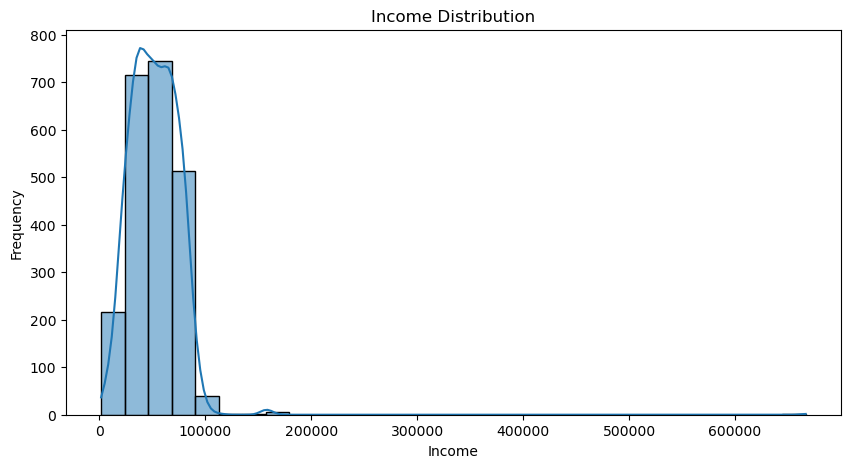

In [27]:
# Income Distribution
plt.figure(figsize=(10,5))

sns.histplot(
    marketing_csv['Income'],
    kde=True,
    bins=30
)

plt.title('Income Distribution')
plt.xlabel('Income')
plt.ylabel('Frequency')

plt.show()

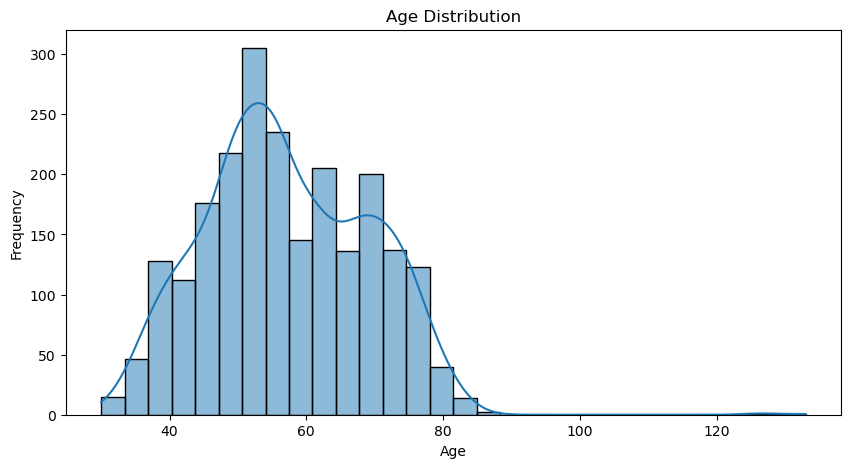

In [28]:
# Age Distribution
plt.figure(figsize=(10,5))

sns.histplot(
    marketing_csv['Age'],
    kde=True,
    bins=30
)

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.show()

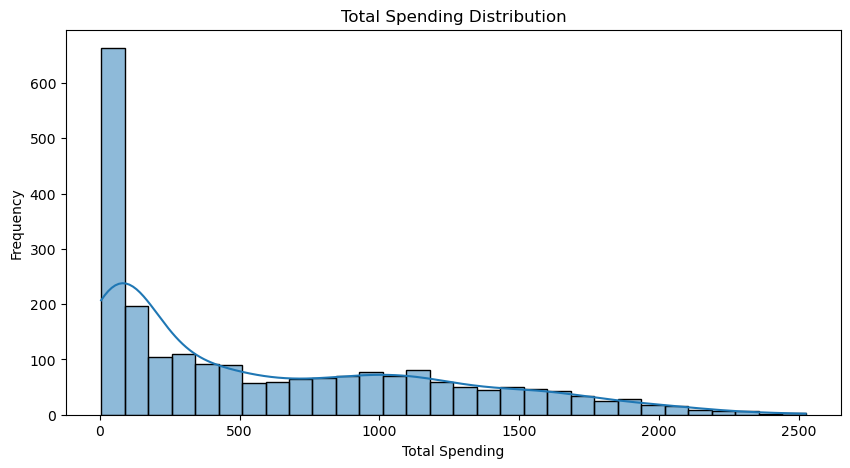

In [29]:
# Total Spending Distribution
plt.figure(figsize=(10,5))

sns.histplot(
    marketing_csv['Total_spent'],
    kde=True,
    bins=30
)

plt.title('Total Spending Distribution')
plt.xlabel('Total Spending')
plt.ylabel('Frequency')

plt.show()

## Income Outliers Detection

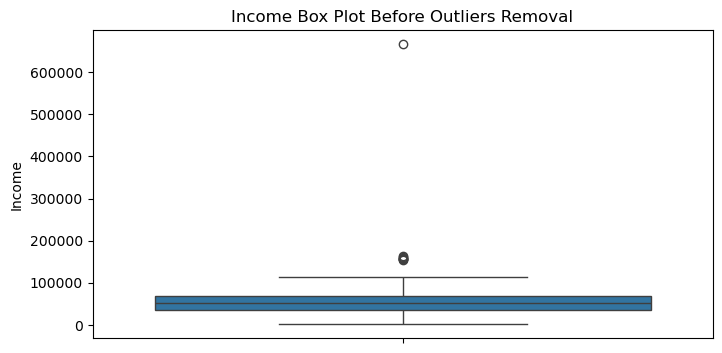

In [30]:
# Outlier detection in Income
plt.figure(figsize=(8,4))
sns.boxplot(marketing_csv['Income'])
plt.title('Income Box Plot Before Outliers Removal')

plt.show()

In [31]:
# Quantiles for IQR
Q1_income = marketing_csv['Income'].quantile(0.25)
Q3_income = marketing_csv['Income'].quantile(0.75)

IQR_income = Q3_income - Q1_income

In [32]:
# Upper bound & Lower bound
lower_bound_income = Q1_income - 1.5 * IQR_income
upper_bound_income = Q3_income + 1.5 * IQR_income

marketing_csv = marketing_csv[(marketing_csv['Income'] >= lower_bound_income) & (marketing_csv['Income'] <= upper_bound_income)]
marketing_csv

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country,Total_children,Age,Total_spent,Total_Purchases
0,1826,1970,Graduation,Divorced,84835.0,0,0,2014-06-16,0,189,...,0,0,0,1,0,SP,0,56,1190,14
1,1,1961,Graduation,Single,57091.0,0,0,2014-06-15,0,464,...,0,0,1,1,0,CA,0,65,577,17
2,10476,1958,Graduation,Married,67267.0,0,1,2014-05-13,0,134,...,0,0,0,0,0,US,1,68,251,10
3,1386,1967,Graduation,Married,32474.0,1,1,2014-05-11,0,10,...,0,0,0,0,0,AUS,2,59,11,3
4,5371,1989,Graduation,Single,21474.0,1,0,2014-04-08,0,6,...,0,0,0,1,0,SP,1,37,91,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10142,1976,PhD,Divorced,66476.0,0,1,2013-03-07,99,372,...,0,0,0,0,0,US,1,50,689,18
2236,5263,1977,Master,Married,31056.0,1,0,2013-01-22,99,5,...,0,0,0,0,0,SP,1,49,55,4
2237,22,1976,Graduation,Divorced,46310.0,1,0,2012-12-03,99,185,...,0,0,0,0,0,SP,1,50,309,12
2238,528,1978,Graduation,Married,65819.0,0,0,2012-11-29,99,267,...,0,0,0,0,0,IND,0,48,1383,19


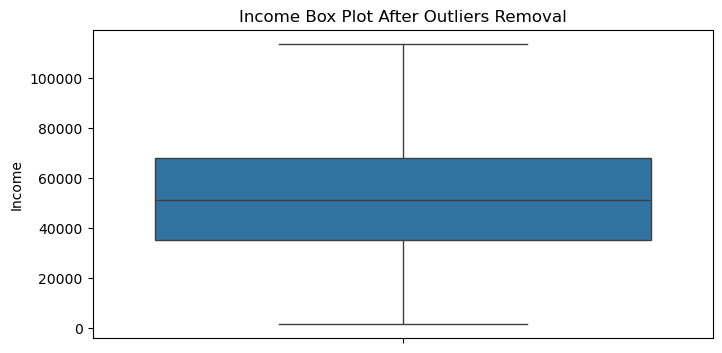

In [33]:
# Outlier detection in Income
plt.figure(figsize=(8,4))
sns.boxplot(marketing_csv['Income'])
plt.title('Income Box Plot After Outliers Removal')

plt.show()

## Total Spending Outlier Detection

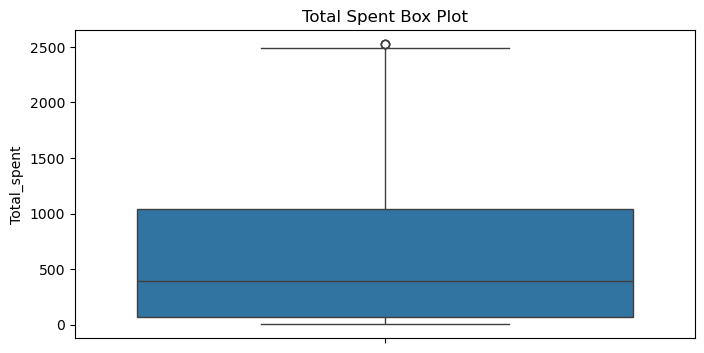

In [34]:
# Outlier detection in Income
plt.figure(figsize=(8,4))
sns.boxplot(marketing_csv['Total_spent'])
plt.title('Total Spent Box Plot')

plt.show()

In [35]:
# IQR for Total Spent
Q1_total_spent = marketing_csv['Total_spent'].quantile(0.25)
Q3_total_spent = marketing_csv['Total_spent'].quantile(0.75)

IQR_total_spent = Q3_total_spent - Q1_total_spent

In [36]:
# Lower bound and Upper bound for Total Spent
lower_total_spent = Q1_total_spent - 1.5 * IQR_total_spent
upper_total_spent = Q3_total_spent + 1.5 * IQR_total_spent

marketing_csv = marketing_csv[(marketing_csv['Total_spent'] >= lower_total_spent) & (marketing_csv['Total_spent'] <= upper_total_spent)]
marketing_csv

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country,Total_children,Age,Total_spent,Total_Purchases
0,1826,1970,Graduation,Divorced,84835.0,0,0,2014-06-16,0,189,...,0,0,0,1,0,SP,0,56,1190,14
1,1,1961,Graduation,Single,57091.0,0,0,2014-06-15,0,464,...,0,0,1,1,0,CA,0,65,577,17
2,10476,1958,Graduation,Married,67267.0,0,1,2014-05-13,0,134,...,0,0,0,0,0,US,1,68,251,10
3,1386,1967,Graduation,Married,32474.0,1,1,2014-05-11,0,10,...,0,0,0,0,0,AUS,2,59,11,3
4,5371,1989,Graduation,Single,21474.0,1,0,2014-04-08,0,6,...,0,0,0,1,0,SP,1,37,91,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10142,1976,PhD,Divorced,66476.0,0,1,2013-03-07,99,372,...,0,0,0,0,0,US,1,50,689,18
2236,5263,1977,Master,Married,31056.0,1,0,2013-01-22,99,5,...,0,0,0,0,0,SP,1,49,55,4
2237,22,1976,Graduation,Divorced,46310.0,1,0,2012-12-03,99,185,...,0,0,0,0,0,SP,1,50,309,12
2238,528,1978,Graduation,Married,65819.0,0,0,2012-11-29,99,267,...,0,0,0,0,0,IND,0,48,1383,19


Number of rows equal before and after outlier removal. So no outliers in the Total_Spent.

Total Number of rows : 2232

## Age Outlier Detection

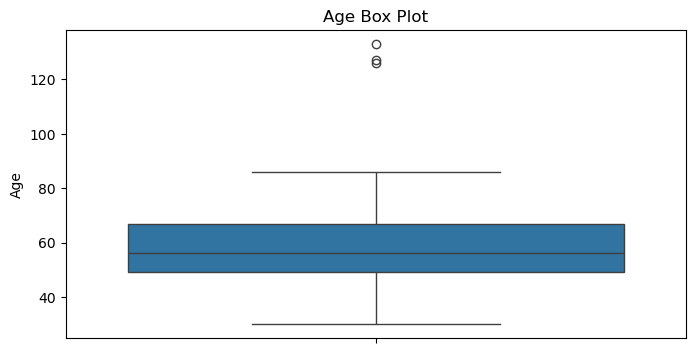

In [37]:
# Outlier detection in Age
plt.figure(figsize=(8,4))
sns.boxplot(marketing_csv['Age'])
plt.title('Age Box Plot')

plt.show()

In [38]:
## IQR for Age
Q1_age = marketing_csv['Age'].quantile(0.25)
Q3_age = marketing_csv['Age'].quantile(0.75)

IQR_age = Q3_age - Q1_age

In [39]:
## Lower bound age and Upper bound age
lower_bound_age = Q1_age - 1.5 * IQR_age
upper_bound_age = Q3_age + 1.5 * IQR_age

marketing_csv = marketing_csv [ (marketing_csv['Age'] >= lower_bound_age) & (marketing_csv['Age'] <= upper_bound_age) ] 
marketing_csv

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country,Total_children,Age,Total_spent,Total_Purchases
0,1826,1970,Graduation,Divorced,84835.0,0,0,2014-06-16,0,189,...,0,0,0,1,0,SP,0,56,1190,14
1,1,1961,Graduation,Single,57091.0,0,0,2014-06-15,0,464,...,0,0,1,1,0,CA,0,65,577,17
2,10476,1958,Graduation,Married,67267.0,0,1,2014-05-13,0,134,...,0,0,0,0,0,US,1,68,251,10
3,1386,1967,Graduation,Married,32474.0,1,1,2014-05-11,0,10,...,0,0,0,0,0,AUS,2,59,11,3
4,5371,1989,Graduation,Single,21474.0,1,0,2014-04-08,0,6,...,0,0,0,1,0,SP,1,37,91,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10142,1976,PhD,Divorced,66476.0,0,1,2013-03-07,99,372,...,0,0,0,0,0,US,1,50,689,18
2236,5263,1977,Master,Married,31056.0,1,0,2013-01-22,99,5,...,0,0,0,0,0,SP,1,49,55,4
2237,22,1976,Graduation,Divorced,46310.0,1,0,2012-12-03,99,185,...,0,0,0,0,0,SP,1,50,309,12
2238,528,1978,Graduation,Married,65819.0,0,0,2012-11-29,99,267,...,0,0,0,0,0,IND,0,48,1383,19


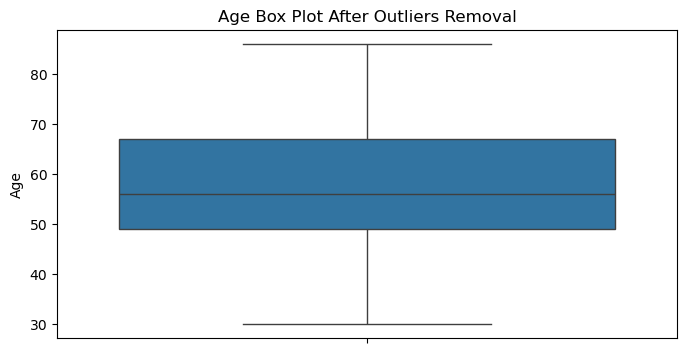

In [40]:
# Outlier detection in Age
plt.figure(figsize=(8,4))
sns.boxplot(marketing_csv['Age'])
plt.title('Age Box Plot After Outliers Removal')

plt.show()

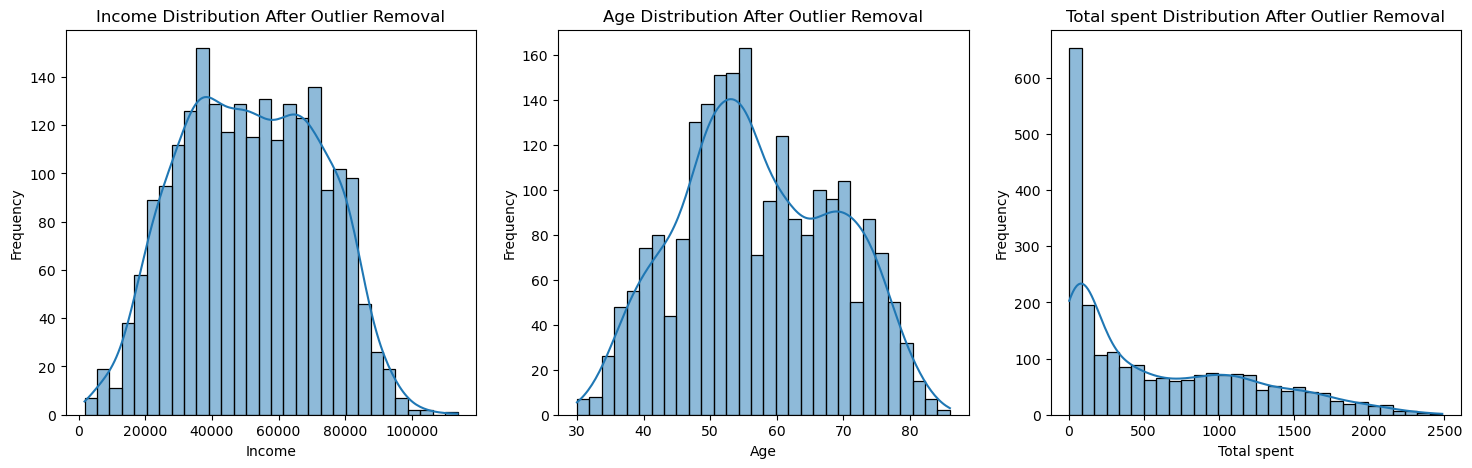

In [41]:
# Distributions after outliers removal
plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
sns.histplot(
    marketing_csv['Income'],
    kde=True,
    bins=30
)

plt.title('Income Distribution After Outlier Removal')
plt.xlabel('Income')
plt.ylabel('Frequency')

plt.subplot(1,3,2)
sns.histplot(
    marketing_csv['Age'],
    kde=True,
    bins=30
)

plt.title('Age Distribution After Outlier Removal')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.subplot(1,3,3)
sns.histplot(
    marketing_csv['Total_spent'],
    kde=True,
    bins=30
)

plt.title('Total spent Distribution After Outlier Removal')
plt.xlabel('Total spent')
plt.ylabel('Frequency')

plt.show()

In [42]:
marketing_csv.reset_index(drop=True, inplace=True)
marketing_csv

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country,Total_children,Age,Total_spent,Total_Purchases
0,1826,1970,Graduation,Divorced,84835.0,0,0,2014-06-16,0,189,...,0,0,0,1,0,SP,0,56,1190,14
1,1,1961,Graduation,Single,57091.0,0,0,2014-06-15,0,464,...,0,0,1,1,0,CA,0,65,577,17
2,10476,1958,Graduation,Married,67267.0,0,1,2014-05-13,0,134,...,0,0,0,0,0,US,1,68,251,10
3,1386,1967,Graduation,Married,32474.0,1,1,2014-05-11,0,10,...,0,0,0,0,0,AUS,2,59,11,3
4,5371,1989,Graduation,Single,21474.0,1,0,2014-04-08,0,6,...,0,0,0,1,0,SP,1,37,91,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2221,10142,1976,PhD,Divorced,66476.0,0,1,2013-03-07,99,372,...,0,0,0,0,0,US,1,50,689,18
2222,5263,1977,Master,Married,31056.0,1,0,2013-01-22,99,5,...,0,0,0,0,0,SP,1,49,55,4
2223,22,1976,Graduation,Divorced,46310.0,1,0,2012-12-03,99,185,...,0,0,0,0,0,SP,1,50,309,12
2224,528,1978,Graduation,Married,65819.0,0,0,2012-11-29,99,267,...,0,0,0,0,0,IND,0,48,1383,19


<h4 style="color:purple">5. Apply ordinal and one-hot encoding based on the various types of categorical variables.</h4> 

In [43]:
marketing_csv.dtypes

ID                              int64
Year_Birth                      int64
Education                      object
Marital_Status                 object
Income                        float64
Kidhome                         int64
Teenhome                        int64
Dt_Customer            datetime64[ns]
Recency                         int64
MntWines                        int64
MntFruits                       int64
MntMeatProducts                 int64
MntFishProducts                 int64
MntSweetProducts                int64
MntGoldProds                    int64
NumDealsPurchases               int64
NumWebPurchases                 int64
NumCatalogPurchases             int64
NumStorePurchases               int64
NumWebVisitsMonth               int64
AcceptedCmp3                    int64
AcceptedCmp4                    int64
AcceptedCmp5                    int64
AcceptedCmp1                    int64
AcceptedCmp2                    int64
Response                        int64
Complain    

In [44]:
marketing_csv['Education'].unique()

array(['Graduation', 'PhD', 'Master', 'Basic'], dtype=object)

In [45]:
marketing_csv['Marital_Status'].unique()

array(['Divorced', 'Single', 'Married', 'Widow'], dtype=object)

In [46]:
marketing_csv['Country'].unique()

array(['SP', 'CA', 'US', 'AUS', 'GER', 'IND', 'SA', 'ME'], dtype=object)

## Encoding for Education Variable

The `Education` variable contains ordered categories representing qualification levels.

Since the alphabetical order also matches the educational hierarchy in this dataset:

| Education | Encoded Value |
|---|---|
| Basic | 0 |
| Graduation | 1 |
| Master | 2 |
| PhD | 3 |

Label Encoding produces the same result as Ordinal Encoding.

---

In [47]:
# Apply label encoding
marketing_csv = marketing_csv[marketing_csv['Age'] > 18]
label_encoder = LabelEncoder()
marketing_csv.loc[:, 'Education_Encoded'] = label_encoder.fit_transform(marketing_csv['Education'])

# After label encoding
marketing_csv[['Education','Education_Encoded']].head()

,Education,Education_Encoded
0,Graduation,1
1,Graduation,1
2,Graduation,1
3,Graduation,1
4,Graduation,1


In [48]:
marketing_csv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2226 entries, 0 to 2225
Data columns (total 33 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2226 non-null   int64         
 1   Year_Birth           2226 non-null   int64         
 2   Education            2226 non-null   object        
 3   Marital_Status       2226 non-null   object        
 4   Income               2226 non-null   float64       
 5   Kidhome              2226 non-null   int64         
 6   Teenhome             2226 non-null   int64         
 7   Dt_Customer          2226 non-null   datetime64[ns]
 8   Recency              2226 non-null   int64         
 9   MntWines             2226 non-null   int64         
 10  MntFruits            2226 non-null   int64         
 11  MntMeatProducts      2226 non-null   int64         
 12  MntFishProducts      2226 non-null   int64         
 13  MntSweetProducts     2226 non-nul

## Encoding for Marital Status Variable

In [49]:
# Apply one hot encoding on Marital_Status
OHE = OneHotEncoder(
    sparse_output=False,
    dtype=int
)
Marital_status_data = OHE.fit_transform(marketing_csv[['Marital_Status']])
encoded_maritalstatus_df = pd.DataFrame(Marital_status_data,
    columns=OHE.get_feature_names_out(['Marital_Status']))

# Verify datatypes
encoded_maritalstatus_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2226 entries, 0 to 2225
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Marital_Status_Divorced  2226 non-null   int64
 1   Marital_Status_Married   2226 non-null   int64
 2   Marital_Status_Single    2226 non-null   int64
 3   Marital_Status_Widow     2226 non-null   int64
dtypes: int64(4)
memory usage: 69.7 KB


In [50]:
marketing_csv.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country,Total_children,Age,Total_spent,Total_Purchases,Education_Encoded
0,1826,1970,Graduation,Divorced,84835.0,0,0,2014-06-16,0,189,...,0,0,1,0,SP,0,56,1190,14,1
1,1,1961,Graduation,Single,57091.0,0,0,2014-06-15,0,464,...,0,1,1,0,CA,0,65,577,17,1
2,10476,1958,Graduation,Married,67267.0,0,1,2014-05-13,0,134,...,0,0,0,0,US,1,68,251,10,1
3,1386,1967,Graduation,Married,32474.0,1,1,2014-05-11,0,10,...,0,0,0,0,AUS,2,59,11,3,1
4,5371,1989,Graduation,Single,21474.0,1,0,2014-04-08,0,6,...,0,0,1,0,SP,1,37,91,6,1


In [51]:
marketing_final_data = pd.concat([marketing_csv,encoded_maritalstatus_df],axis=1)

In [52]:
marketing_final_data.drop(
    columns=['Marital_Status','Education'],
    inplace=True
)

In [53]:
marketing_final_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2226 entries, 0 to 2225
Data columns (total 35 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   ID                       2226 non-null   int64         
 1   Year_Birth               2226 non-null   int64         
 2   Income                   2226 non-null   float64       
 3   Kidhome                  2226 non-null   int64         
 4   Teenhome                 2226 non-null   int64         
 5   Dt_Customer              2226 non-null   datetime64[ns]
 6   Recency                  2226 non-null   int64         
 7   MntWines                 2226 non-null   int64         
 8   MntFruits                2226 non-null   int64         
 9   MntMeatProducts          2226 non-null   int64         
 10  MntFishProducts          2226 non-null   int64         
 11  MntSweetProducts         2226 non-null   int64         
 12  MntGoldProds             2226 non-

In [54]:
marketing_final_data.head()

,ID,Year_Birth,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,Country,Total_children,Age,Total_spent,Total_Purchases,Education_Encoded,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Widow
0,1826,1970,84835.0,0,0,2014-06-16,0,189,104,379,...,SP,0,56,1190,14,1,1,0,0,0
1,1,1961,57091.0,0,0,2014-06-15,0,464,5,64,...,CA,0,65,577,17,1,0,0,1,0
2,10476,1958,67267.0,0,1,2014-05-13,0,134,11,59,...,US,1,68,251,10,1,0,1,0,0
3,1386,1967,32474.0,1,1,2014-05-11,0,10,0,1,...,AUS,2,59,11,3,1,0,1,0,0
4,5371,1989,21474.0,1,0,2014-04-08,0,6,16,24,...,SP,1,37,91,6,1,0,0,1,0


<h4 style="color:purple">6. Generate a heatmap to illustrate the correlation between different pairs of variables.</h4> 

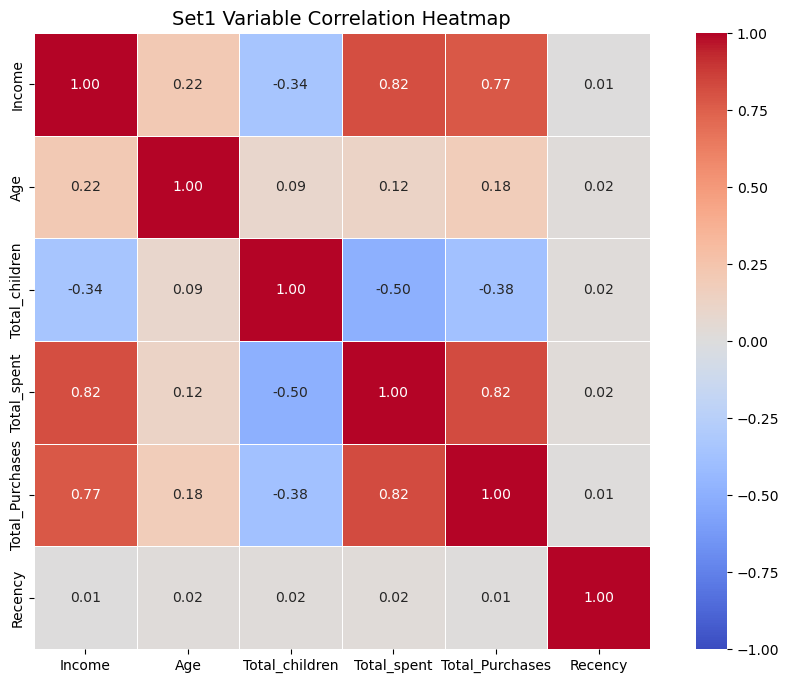

In [55]:
correlation_columns_set1 = [
    'Income',
    'Age',
    'Total_children',
    'Total_spent',
    'Total_Purchases',
    'Recency'
]

corr_matrix_set1 = marketing_final_data[
    correlation_columns_set1
].corr()

# 3. Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix_set1, 
            annot=True,          # Displays correlation values in cells
            cmap='coolwarm',     # Color palette (reds for positive, blues for negative)
            vmin=-1, vmax=1,     # Anchors the color scale
            center=0,            # Sets the center to 0 for neutral correlation
            square=True,         # Makes each cell perfectly square
            fmt='.2f',
            linewidths=0.5
           )         

plt.title('Set1 Variable Correlation Heatmap', fontsize=14)
plt.show()

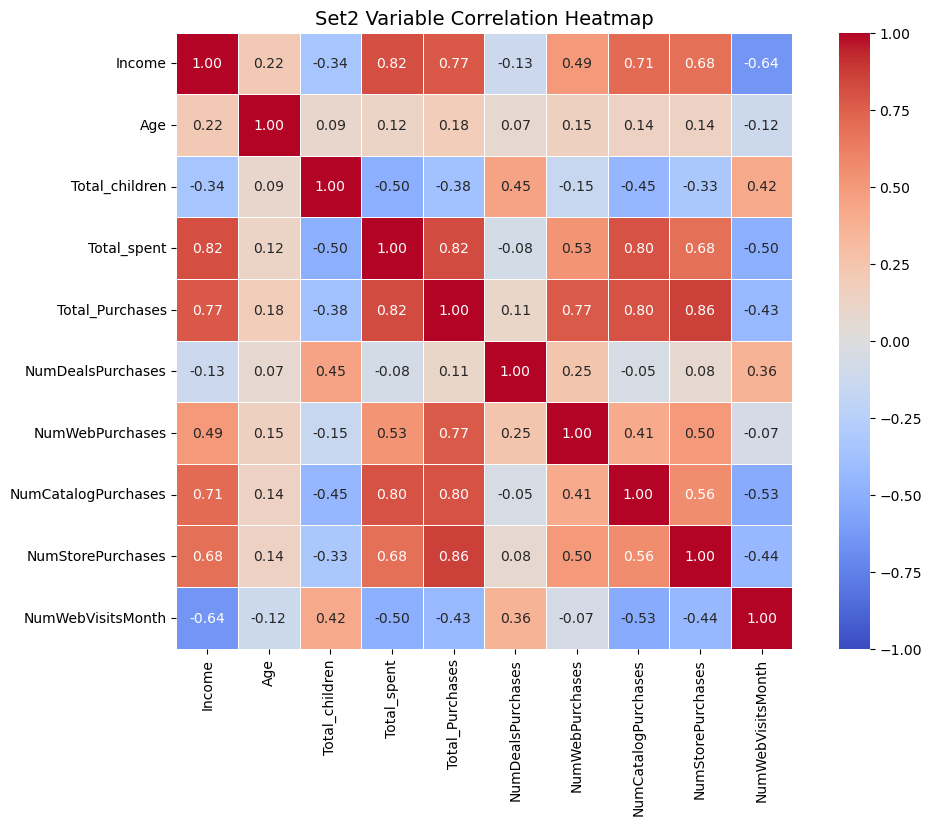

In [56]:
correlation_columns_set2 = [
    'Income',
    'Age',
    'Total_children',
    'Total_spent',
    'Total_Purchases',
    'NumDealsPurchases',
    'NumWebPurchases',
    'NumCatalogPurchases',
    'NumStorePurchases',
    'NumWebVisitsMonth'
]

corr_matrix_set2 = marketing_final_data[
    correlation_columns_set2
].corr()

# 3. Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix_set2, 
            annot=True,          # Displays correlation values in cells
            cmap='coolwarm',     # Color palette (reds for positive, blues for negative)
            vmin=-1, vmax=1,     # Anchors the color scale
            center=0,            # Sets the center to 0 for neutral correlation
            square=True,         # Makes each cell perfectly square
            fmt='.2f',
            linewidths=0.5
           )         

plt.title('Set2 Variable Correlation Heatmap', fontsize=14)
plt.show()


Insights
---
The heatmap visualises the correlation between numerical variables.

1. Income and Total_Spending show a positive correlation.
2. Customers with higher purchases generally spend more.
3. Recency may negatively correlate with spending and purchases.
4. NumWebVisitsMonth appears to be positively correlated with Total_children, indicating that families with children may browse products online more frequently.
5. We can create customer segmentation based on purchase pattern.
6. Improve targeted marketing campaigns based on store purchases because purchases are positive.
7. Focus premium product campaigns on high-income customers.
8. Improve targeted marketing campaigns for customers with strong store purchase behavior.
9. Use personalized family-oriented offers for customers with children.

Heatmaps provide an easy-to-understand visual summary of relationships between variables.

<h3 style="color:purple"> 7. Hypothesis Testing </h3>

---
#### A. Older individuals may not possess the same level of technological proficiency and may, therefore, lean toward traditional in-store shopping preferences.

---

### Hypothesis Formulation

#### Null Hypothesis (H₀)
There is no relationship between customer age and in-store shopping preference.

#### Alternative Hypothesis (H₁)
Older individuals prefer traditional in-store shopping over online shopping.

---

In [57]:
marketing_oldage_data = marketing_final_data[(marketing_final_data['Age'] >= 60) & (marketing_final_data['Age'] <=90)]
marketing_oldage_data[
    ['Age', 'NumStorePurchases', 'NumWebPurchases']
].corr()

,Age,NumStorePurchases,NumWebPurchases
Age,1.000000,0.085820,0.068961
NumStorePurchases,0.085820,1.000000,0.412453
NumWebPurchases,0.068961,0.412453,1.000000


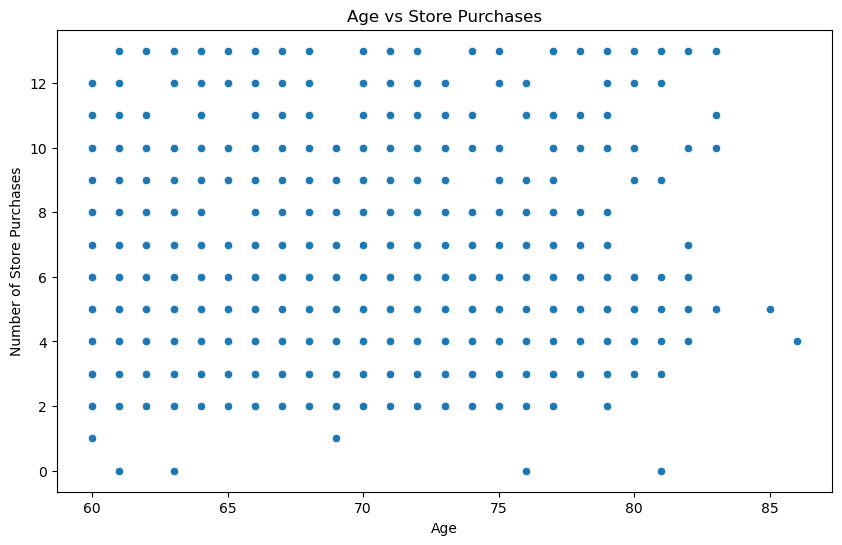

In [58]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='Age',
    y='NumStorePurchases',
    data=marketing_oldage_data
)

plt.title('Age vs Store Purchases')
plt.xlabel('Age')
plt.ylabel('Number of Store Purchases')

plt.show()

In [59]:
marketing_final_data.groupby(
    pd.cut(
        marketing_final_data['Age'],
        bins=[18,30,45,60,90]
    ),
    observed=False
)[
    ['NumStorePurchases', 'NumWebPurchases']
].mean()

,NumStorePurchases,NumWebPurchases
Age,,
"(18, 30]",2.500000,2.000000
"(30, 45]",5.263852,3.456464
"(45, 60]",5.535895,3.978766
"(60, 90]",6.367991,4.529206


### Fail to Reject the Null Hypothesis

- Age has a very weak positive correlation with both:
  - store purchases
  - web purchases

- This indicates that age alone is not a strong factor influencing shopping channel preference.

- Customers across age groups appear to use both:
  - online channels
  - physical stores
    
1. Older customers still engage with online shopping platforms.
2. Younger customers show stronger engagement with web purchases.
3. This suggests that technological familiarity and shopping habits may influence other factors as well.

The analysis supports that older individuals may prefer traditional in-store shopping methods and also online purchasing channels.

However, the relationship is extremely small, indicating that many older customers also participate in online shopping.

---

#### B. Customers with children likely experience time constraints, making online shopping a more convenient option.

---

#### Hypothesis Formulation

#### Null Hypothesis (H₀)
Customers with children do not show preference toward online shopping.

#### Alternative Hypothesis (H₁)
Customers with children prefer making online shopping due to time constraint.

---

In [60]:
marketing_childparents_data = marketing_final_data[marketing_final_data['Total_children'] > 0]
marketing_childparents_data[
    ['Total_children', 'NumWebPurchases']
].corr()

,Total_children,NumWebPurchases
Total_children,1.000000,-0.172389
NumWebPurchases,-0.172389,1.000000


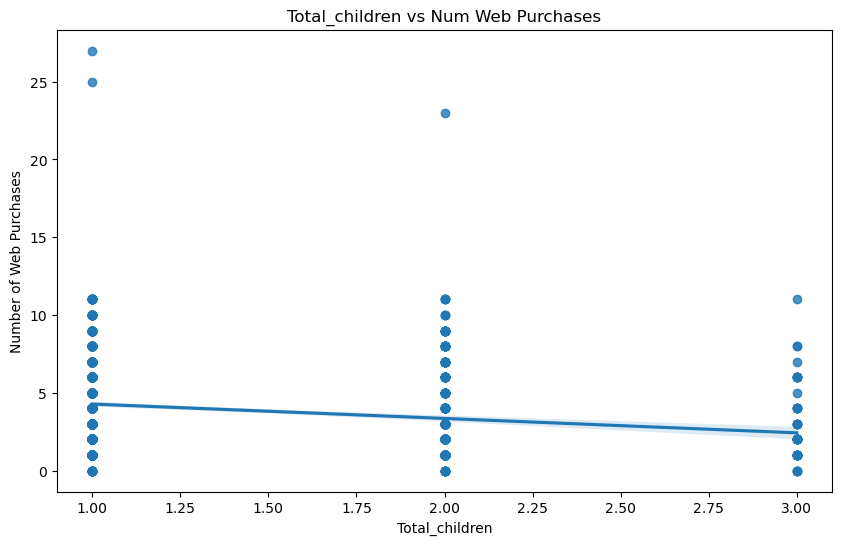

In [61]:
plt.figure(figsize=(10,6))

sns.regplot(
    x='Total_children',
    y='NumWebPurchases',
    data=marketing_childparents_data
)

plt.title('Total_children vs Num Web Purchases')
plt.xlabel('Total_children')
plt.ylabel('Number of Web Purchases')

plt.show()

In [62]:
marketing_childparents_data.groupby(
    'Total_children',
    observed=False
)[
    ['NumStorePurchases', 'NumWebPurchases']
].mean()

,NumStorePurchases,NumWebPurchases
Total_children,,
1,5.611754,4.298308
2,4.319048,3.240476
3,3.962264,2.867925


### Fail to Reject null hypothesis

1. The relationship between children and online purchases is weakly negative.
2. Customers with more children do not necessarily make more web purchases.
3. Families continue using multiple shopping channels.
4. Do not assume parents prefer only online shopping.
5. Additional factors such as income and lifestyle likely influence shopping behavior more strongly.

---

#### C. Sales at physical stores may face the risk of cannibalization by alternative distribution channels.

---

#### Hypothesis Formulation

#### Null Hypothesis (H₀)
Sales at physical stores are not affected by alternative channels.

#### Alternative Hypothesis (H₁)
Sales at physical stores are afftecting by alternative distribution channels.

---

In [63]:
marketing_final_data[
    ['NumStorePurchases', 'NumWebPurchases','NumCatalogPurchases']
].corr()

,NumStorePurchases,NumWebPurchases,NumCatalogPurchases
NumStorePurchases,1.000000,0.499154,0.561309
NumWebPurchases,0.499154,1.000000,0.411208
NumCatalogPurchases,0.561309,0.411208,1.000000


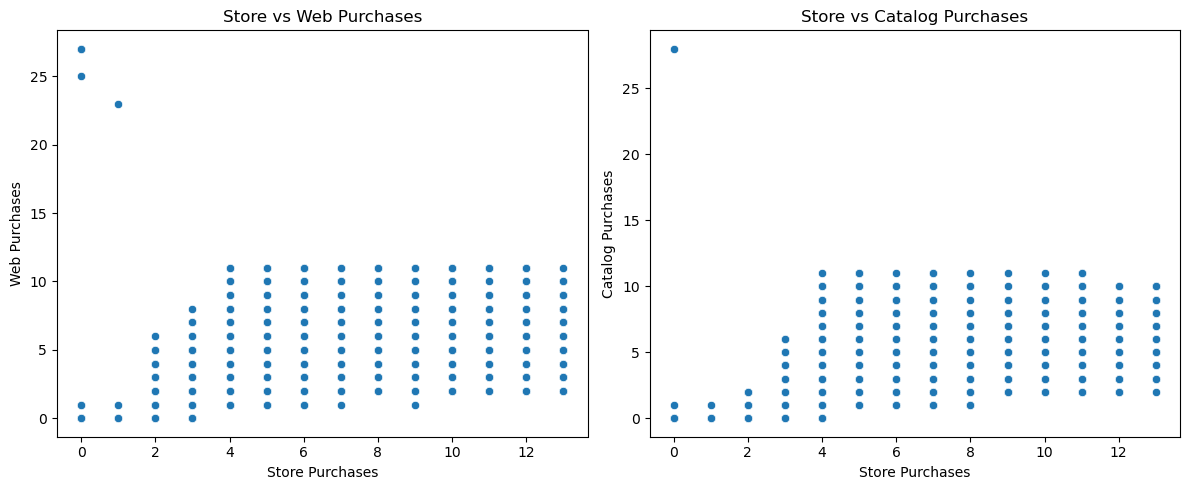

In [85]:
plt.figure(figsize=(12,5))

# Store vs Web Purchases
plt.subplot(1,2,1)

sns.scatterplot(
    x='NumStorePurchases',
    y='NumWebPurchases',
    data=marketing_final_data
)

plt.title('Store vs Web Purchases')
plt.xlabel('Store Purchases')
plt.ylabel('Web Purchases')

# Store vs Catalog Purchases
plt.subplot(1,2,2)

sns.scatterplot(
    x='NumStorePurchases',
    y='NumCatalogPurchases',
    data=marketing_final_data
)

plt.title('Store vs Catalog Purchases')
plt.xlabel('Store Purchases')
plt.ylabel('Catalog Purchases')

plt.tight_layout()

plt.show()

### Fail to Reject null hypothesis

- All correlations are positive and moderate in strength.
- Customers purchasing through one channel also tend to purchase through other channels.
- There is no evidence of strong negative correlation between store purchases and alternative channels.

---

The analysis does not support the hypothesis that physical store sales are being cannibalised by alternative distribution channels.

1. Customers who shop online also continue making physical store purchases.

2. Catalog purchases show strong positive relationships with store purchases.


---

#### D. Does the United States significantly outperform the rest of the world in total purchase volumes

---

#### Hypothesis Formulation

#### Null Hypothesis (H₀)
No significant difference between the United States with other countries.

#### Alternative Hypothesis (H₁)
The United States significantly outperforms the rest of the countries in total purchase volumes.

---

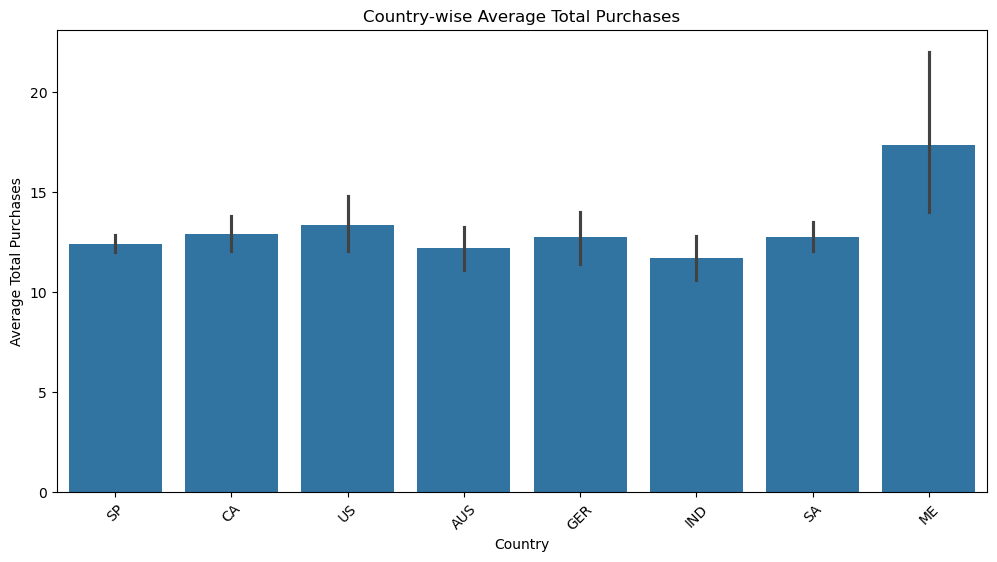

In [65]:
plt.figure(figsize=(12,6))

sns.barplot(
    x='Country',
    y='Total_Purchases',
    data=marketing_final_data,
    estimator='mean'
)
plt.title('Country-wise Average Total Purchases')
plt.xlabel('Country')
plt.ylabel('Average Total Purchases')
plt.xticks(rotation=45)

plt.show()

In [66]:
marketing_final_data.groupby('Country')['Total_Purchases'].mean().sort_values(ascending=False)

Country
ME     17.333333
US     13.370370
CA     12.890977
SA     12.753754
GER    12.750000
SP     12.430275
AUS    12.200000
IND    11.691781
Name: Total_Purchases, dtype: float64

In [67]:
from scipy.stats import ttest_ind

us_data = marketing_final_data[ marketing_final_data['Country'] == 'US' ]['Total_Purchases']

rest_world_data = marketing_final_data[ marketing_final_data['Country'] != 'US' ]['Total_Purchases']

t_stat, p_value = ttest_ind(
    us_data,
    rest_world_data,
    equal_var=False
)

print('T-statistic :', t_stat)

print('P-value :', p_value)

T-statistic : 1.2667417917830992
P-value : 0.20772490174808034


In [68]:
if p_value < 0.05:
    print('Reject Null Hypothesis')
else:
    print('Fail to Reject Null Hypothesis')

Fail to Reject Null Hypothesis


Fail to Reject the Null Hypothesis

There is insufficient statistical evidence to conclude that the United States significantly outperforms other countries in total purchase volumes.


<h3 style="color:purple"> 8. Use appropriate visualization to help analyze the following: </h3>

---

#### A. Identify the top-performing products and those with the lowest revenue.


In [69]:
marketing_final_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2226 entries, 0 to 2225
Data columns (total 35 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   ID                       2226 non-null   int64         
 1   Year_Birth               2226 non-null   int64         
 2   Income                   2226 non-null   float64       
 3   Kidhome                  2226 non-null   int64         
 4   Teenhome                 2226 non-null   int64         
 5   Dt_Customer              2226 non-null   datetime64[ns]
 6   Recency                  2226 non-null   int64         
 7   MntWines                 2226 non-null   int64         
 8   MntFruits                2226 non-null   int64         
 9   MntMeatProducts          2226 non-null   int64         
 10  MntFishProducts          2226 non-null   int64         
 11  MntSweetProducts         2226 non-null   int64         
 12  MntGoldProds             2226 non-

In [70]:
product_sales = {
    'Wines': marketing_final_data['MntWines'].sum(),
    'Fruits': marketing_final_data['MntFruits'].sum(),
    'Meat': marketing_final_data['MntMeatProducts'].sum(),
    'Fish': marketing_final_data['MntFishProducts'].sum(),
    'Sweets': marketing_final_data['MntSweetProducts'].sum(),
    'Gold': marketing_final_data['MntGoldProds'].sum()
}
product_sales_df = pd.DataFrame(product_sales.items(),columns=['Product', 'Revenue'])
product_sales_df.sort_values('Revenue',ascending=False)

,Product,Revenue
0,Wines,676255
2,Meat,365773
5,Gold,98103
3,Fish,83620
4,Sweets,60107
1,Fruits,58319


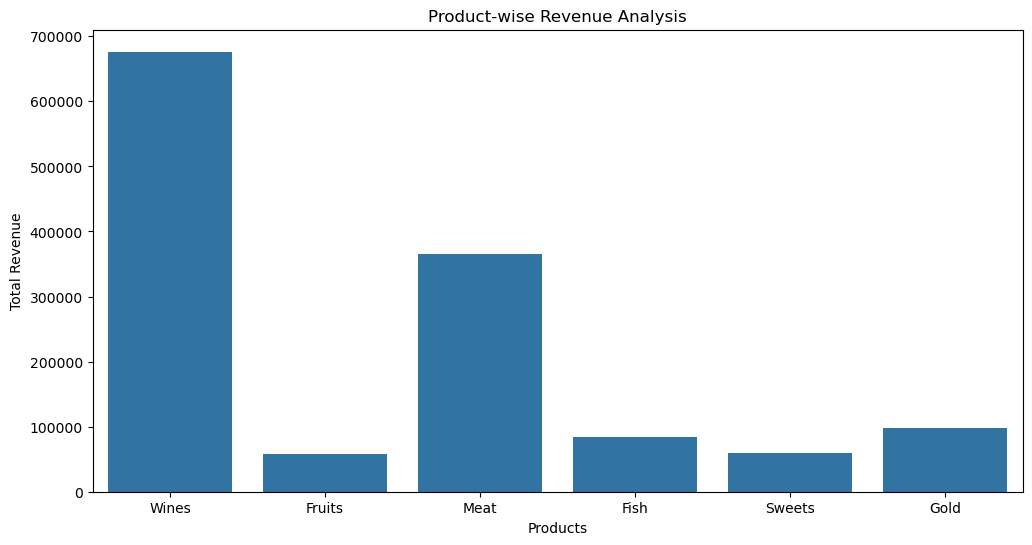

In [71]:
plt.figure(figsize=(12,6))

sns.barplot(
    x='Product',
    y='Revenue',
    data=product_sales_df
)
plt.title('Product-wise Revenue Analysis')
plt.xlabel('Products')
plt.ylabel('Total Revenue')

plt.show()

In [72]:
highest_revenue_product = product_sales_df.iloc[product_sales_df['Revenue'].idxmax()]

lowest_revenue_product = product_sales_df.iloc[product_sales_df['Revenue'].idxmin()]

print('Highest Revenue Product:')
print(highest_revenue_product)

print('\nLowest Revenue Product:')
print(lowest_revenue_product)

Highest Revenue Product:
Product     Wines
Revenue    676255
Name: 0, dtype: object

Lowest Revenue Product:
Product    Fruits
Revenue     58319
Name: 1, dtype: object


#### Observations
1. High-revenue products should receive:
    - premium marketing focus
    - inventory prioritization
    - personalized recommendations
    
2. Low-revenue products may need:
    - bundled offers / discounts

---

#### B. Examine if there is a correlation between customers' age and the acceptance rate of the last campaign.

---

In [73]:
marketing_final_data[['Age','Response']].corr()

,Age,Response
Age,1.00000,-0.01558
Response,-0.01558,1.00000


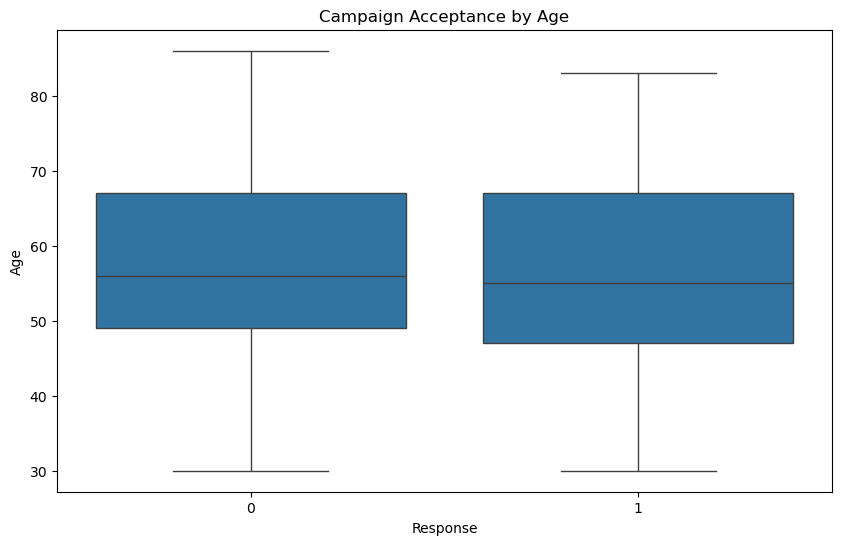

In [74]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='Response',
    y='Age',
    data=marketing_final_data
)

plt.title('Campaign Acceptance by Age')
plt.xlabel('Response')
plt.ylabel('Age')

plt.show()

In [75]:
marketing_final_data.groupby(
    pd.cut(
        marketing_final_data['Age'],
        bins=[18,30,45,60,90]
    ),
    observed=False
)[
    'Response'
].mean()

Age
(18, 30]    0.500000
(30, 45]    0.192612
(45, 60]    0.140546
(60, 90]    0.139019
Name: Response, dtype: float64

#### Fail to Reject the Null Hypothesis

1. This indicates an extremely weak negative correlation between customer age and campaign acceptance.
2. The correlation value is very close to zero.
3. Age does not appear to strongly influence whether customers accept the last marketing campaign.
5. The analysis does not support the hypothesis that customer age significantly affects the acceptance rate of the last campaign.

The relationship between age and campaign response is extremely weak and practically negligible.

#### Interpretation

- Younger customers (18–30) show the highest campaign acceptance rate.
- Campaign acceptance decreases as age increases.
- Customers above 45 years show relatively lower response rates toward the last campaign.

This indicates a negative relationship between age and campaign acceptance behavior.

---

#### C. Determine the country with the highest number of customers who accepted the last campaign.

---

In [76]:
marketing_country_data = marketing_final_data.groupby('Country')['Response'].sum().reset_index()
highest_country = marketing_country_data.iloc[marketing_country_data['Response'].idxmax()]
print('Country with Highest Campaign Acceptance :',highest_country['Country'])
print('Number of Accepted Customers :',highest_country['Response'])

Country with Highest Campaign Acceptance : SP
Number of Accepted Customers : 176


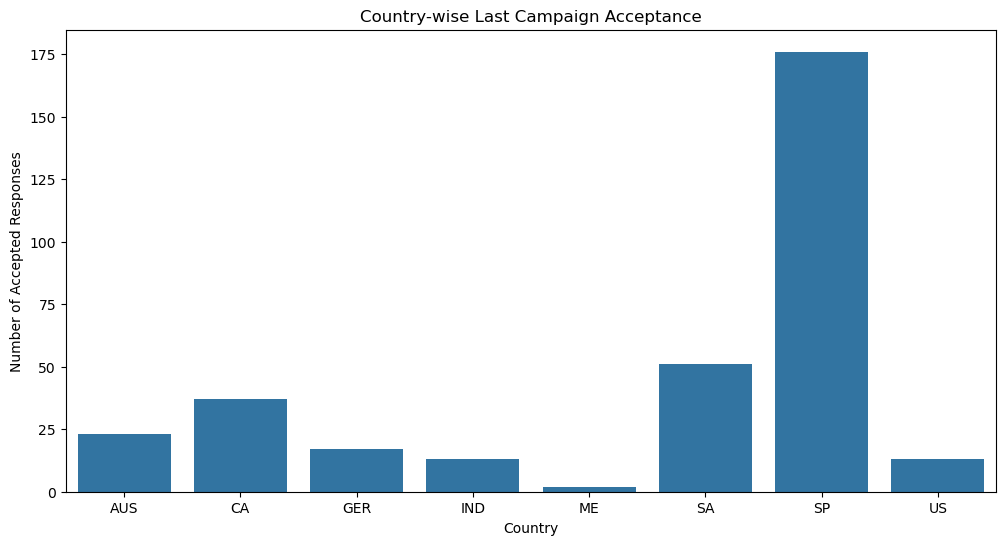

In [77]:
plt.figure(figsize=(12,6))

sns.barplot(
    x='Country',
    y='Response',
    data = marketing_country_data
)

plt.title('Country-wise Last Campaign Acceptance')
plt.xlabel('Country')
plt.ylabel('Number of Accepted Responses')

plt.show()

### Observations

1. The country with the tallest bar represents the highest number of customers who accepted the last campaign.
2. Countries with lower values indicate lower customer engagement with marketing campaigns.
3. Campaign acceptance behavior varies across geographic regions.

---

#### D. Investigate if there is a discernible pattern in the number of children at home and the total expenditure.

---

In [78]:
marketing_final_data[['Total_children','Total_spent']].corr()

,Total_children,Total_spent
Total_children,1.000000,-0.498032
Total_spent,-0.498032,1.000000


In [79]:
children_spending_analysis = marketing_final_data.groupby(
    'Total_children',
    observed=False
)[
    'Total_spent'
].mean()

children_spending_analysis

Total_children
0    1099.617460
1     473.220837
2     246.278571
3     274.603774
Name: Total_spent, dtype: float64

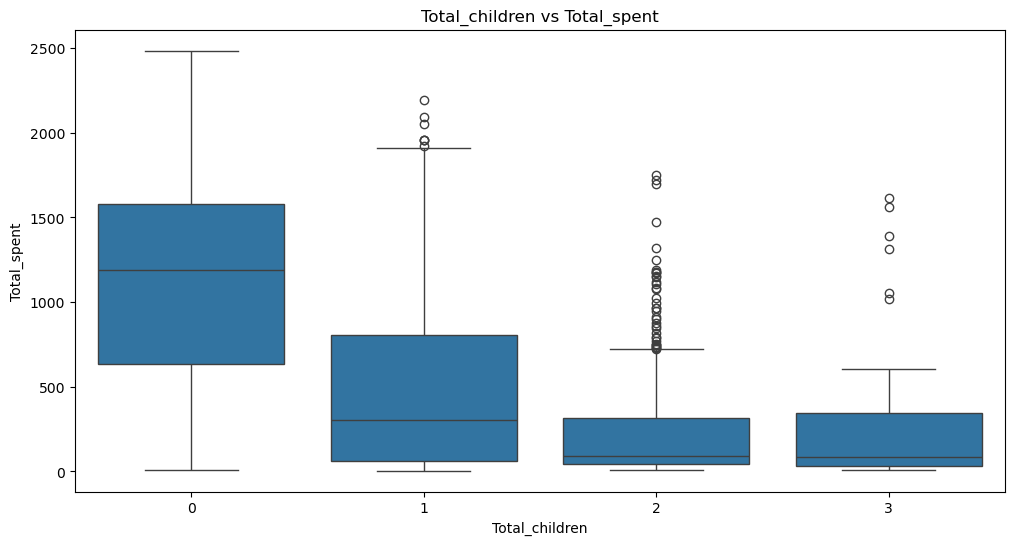

In [80]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x='Total_children',
    y='Total_spent',
    data = marketing_final_data
)

plt.title('Total_children vs Total_spent')
plt.xlabel('Total_children')
plt.ylabel('Total_spent')

plt.show()

#### Observation

There is a pattern between the number of children at home and total expenditure.
As the number of children increases, average customer spending generally decreases.

- Customers without children have the highest average spending.
- Total expenditure decreases significantly as the number of children increases.
- Customers with:
  - 1 child spend less than half compared to customers without children
  - 2 children show the lowest spending behaviour.
- Customers with 3 children show a slight increase compared to 2 children, but spending remains far lower than households without children.

---

#### Interpretation

The results clearly indicate a negative relationship between:
- household children count
- total customer expenditure

This suggests that customers with more children may:
- have tighter financial budgets
- prioritize essential spending
- demonstrate more price-sensitive purchasing behavior

Customers without children likely have:
- higher disposable income
- greater spending flexibility
- stronger premium product purchasing capacity

---

#### Business Insight

##### Customers Without Children
Suitable for:
- premium products
- personalized recommendations
- upselling strategies

##### Families With Children
Suitable for:
- bundled offers
- discounts
- value packs
- budget-oriented campaigns

---

#### Recommendation

- Create customer segments based on household size.
- Offer family-focused promotions for larger households.
- Use personalized pricing and product recommendations.


---

#### E. Analyze the educational background of customers who lodged complaints in the last two years.

---

In [81]:
marketing_final_data[['Education_Encoded', 'Complain']].corr()

,Education_Encoded,Complain
Education_Encoded,1.000000,-0.035526
Complain,-0.035526,1.000000


In [82]:
marketing_edu_complain = marketing_final_data.groupby('Education_Encoded')['Complain'].sum().reset_index()
marketing_edu_complain

,Education_Encoded,Complain
0,0,0
1,1,14
2,2,5
3,3,1


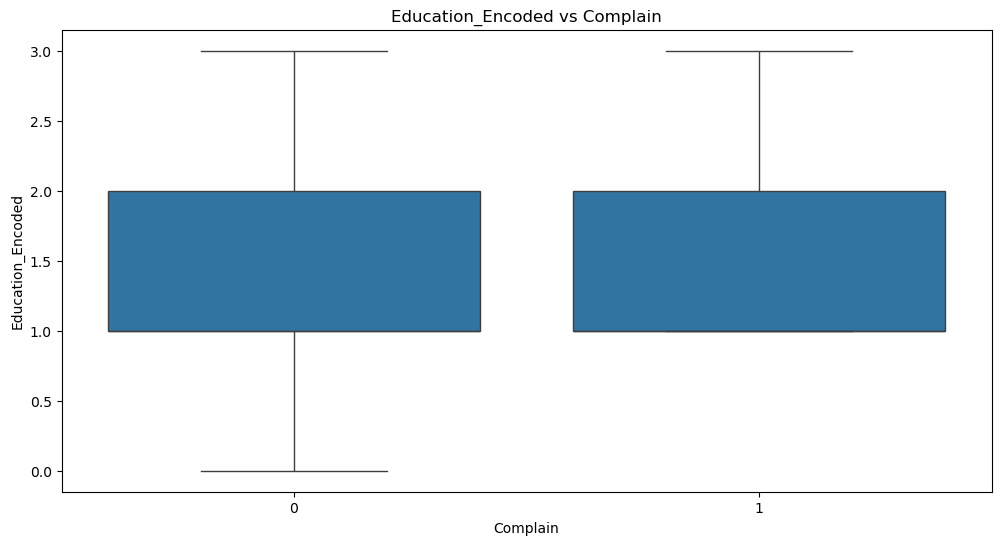

In [83]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x='Complain',
    y='Education_Encoded',
    data = marketing_final_data
)

plt.title('Education_Encoded vs Complain')
plt.xlabel('Complain')
plt.ylabel('Education_Encoded')

plt.show()

#### Observations

This indicates an extremely weak negative correlation between educational background and customer complaints.

Interpretation
The correlation value is very close to zero.
Education level does not strongly influence whether customers lodge complaints.

The analysis does not support a significant relationship between customer education level and complaint behavior.

Educational background appears to have minimal impact on whether customers lodged complaints during the last two years.

#### Insights
Complaint behavior is relatively independent of educational background.

Customer dissatisfaction likely depends more on:
- service quality
- product experience
- support responsiveness
- pricing
- delivery experience


#### Recommendation

Can improve:

customer satisfaction
service quality
overall customer experience